In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Чтение файла
df = pd.read_csv('Churn_Modelling.csv')

In [2]:
#Общая информаия

In [3]:
df.shape

(10000, 14)

In [4]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [5]:
# Проверяем наличие пропусков
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

print("Пропуски в данных:")
print(missing_values)

Пропуски в данных:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


Выводы:

Датасет содержит 10000 строк и 14 столбцов<br>
Типы данных соответствуют ожидаемым<br>
Пропуски отсутствуют<br>
Дубли отсутствуют

In [ ]:
#Описательные статистики

In [7]:
# Вывод описательных статистик для всех переменных
descriptive_stats = df.describe(include='all')

# Вывод результата
print(descriptive_stats)

          RowNumber    CustomerId Surname   CreditScore Geography Gender  \
count   10000.00000  1.000000e+04   10000  10000.000000     10000  10000   
unique          NaN           NaN    2932           NaN         3      2   
top             NaN           NaN   Smith           NaN    France   Male   
freq            NaN           NaN      32           NaN      5014   5457   
mean     5000.50000  1.569094e+07     NaN    650.528800       NaN    NaN   
std      2886.89568  7.193619e+04     NaN     96.653299       NaN    NaN   
min         1.00000  1.556570e+07     NaN    350.000000       NaN    NaN   
25%      2500.75000  1.562853e+07     NaN    584.000000       NaN    NaN   
50%      5000.50000  1.569074e+07     NaN    652.000000       NaN    NaN   
75%      7500.25000  1.575323e+07     NaN    718.000000       NaN    NaN   
max     10000.00000  1.581569e+07     NaN    850.000000       NaN    NaN   

                 Age        Tenure        Balance  NumOfProducts    HasCrCard  \
count 

1.Числовые переменные:<br>
RowNumber:<br>
Среднее значение: 5000.5, что логично, так как это просто порядковый номер строки.<br>
Минимальное значение: 1, максимальное: 10000, что соответствует количеству строк в данных.<br>

CustomerId:<br>
Среднее значение: 1.56e+07 (15,600,940), стандартное отклонение: 71,936.19.<br>
Минимальное значение: 15,565,700, максимальное: 15,815,590. Это уникальные идентификаторы клиентов.<br>

CreditScore:<br>
Средний кредитный рейтинг: 650.53, стандартное отклонение: 96.65.<br>
Минимальное значение: 350, максимальное: 850. Это соответствует стандартному диапазону кредитных рейтингов.<br>

Age:<br>
Средний возраст клиентов: 38.92 года, стандартное отклонение: 10.49.<br>
Минимальный возраст: 18 лет, максимальный: 92 года. Возраст клиентов варьируется от молодых до пожилых.<br>

Tenure:<br>
Средний срок пребывания клиента: 5.01 года, стандартное отклонение: 2.89.<br>
Минимальное значение: 0 лет, максимальное: 10 лет. Это указывает на то, что некоторые клиенты только что присоединились.<br>

Balance:<br>
Средний баланс на счетах: 76,485.89, стандартное отклонение: 62,397.41.<br>
Минимальное значение: 0, максимальное: 250,898.09. У некоторых клиентов баланс равен нулю, что может указывать на неактивные счета.

NumOfProducts:<br>
Среднее количество продуктов: 1.53, стандартное отклонение: 0.58.<br>
Минимальное значение: 1, максимальное: 4. Большинство клиентов используют 1-2 продукта.<br>

HasCrCard:<br>
Среднее значение: 0.7055, что означает, что около 70.55% клиентов имеют кредитную карту.<br>

IsActiveMember:<br>
Среднее значение: 0.5151, что означает, что около 51.51% клиентов являются активными.<br>

EstimatedSalary:<br>
Средняя зарплата: 100,000.24, стандартное отклонение: 57,510.49.<br>
Минимальное значение: 11.58, максимальное: 199,992.48. Зарплаты варьируются от очень низких до высоких.<br>

Exited:<br>
Среднее значение: 0.2037, что означает, что около 20.37% клиентов ушли (прекратили пользоваться услугами).<br>

2.Категориальные переменные:<br>
Surname:<br>
Уникальных фамилий: 2932. Наиболее часто встречающаяся фамилия: "Smith" (32 раза).<br>

Geography:<br>
Уникальных значений: 3. Наиболее часто встречающаяся страна: "France" (5014 раз).<br>

Gender:<br>
Уникальных значений: 2. Наиболее часто встречающийся пол: "Male" (5457 раз).<br>

In [8]:
#Детальная информация по признакам

In [9]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:

# Изучение каждого признака
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:  # Числовые признаки
        min_value = df[column].min()
        max_value = df[column].max()
        print(f"Числовой признак '{column}': диапазон значений от {min_value} до {max_value}")
    else:  # Категориальные признаки
        unique_values = df[column].unique()
        print(f"Категориальный признак '{column}': уникальные значения {unique_values}")

Числовой признак 'RowNumber': диапазон значений от 1 до 10000
Числовой признак 'CustomerId': диапазон значений от 15565701 до 15815690
Категориальный признак 'Surname': уникальные значения ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
Числовой признак 'CreditScore': диапазон значений от 350 до 850
Категориальный признак 'Geography': уникальные значения ['France' 'Spain' 'Germany']
Категориальный признак 'Gender': уникальные значения ['Female' 'Male']
Числовой признак 'Age': диапазон значений от 18 до 92
Числовой признак 'Tenure': диапазон значений от 0 до 10
Числовой признак 'Balance': диапазон значений от 0.0 до 250898.09
Числовой признак 'NumOfProducts': диапазон значений от 1 до 4
Числовой признак 'HasCrCard': диапазон значений от 0 до 1
Числовой признак 'IsActiveMember': диапазон значений от 0 до 1
Числовой признак 'EstimatedSalary': диапазон значений от 11.58 до 199992.48
Числовой признак 'Exited': диапазон значений от 0 до 1


Рассмотрим каждый признак:

RowNumber


In [20]:
import pandas as pd

# Загрузка данных из CSV-файла
df = pd.read_csv('Churn_Modelling.csv')

# Изучение признака RowNumber
print("Описательные статистики для RowNumber:")
print(df['RowNumber'].describe())

print("\nУникальные значения RowNumber:")
print(df['RowNumber'].unique())

print("\nМинимальное значение RowNumber:", df['RowNumber'].min())
print("Максимальное значение RowNumber:", df['RowNumber'].max())

Описательные статистики для RowNumber:
count    10000.00000
mean      5000.50000
std       2886.89568
min          1.00000
25%       2500.75000
50%       5000.50000
75%       7500.25000
max      10000.00000
Name: RowNumber, dtype: float64

Уникальные значения RowNumber:
[    1     2     3 ...  9998  9999 10000]

Минимальное значение RowNumber: 1
Максимальное значение RowNumber: 10000


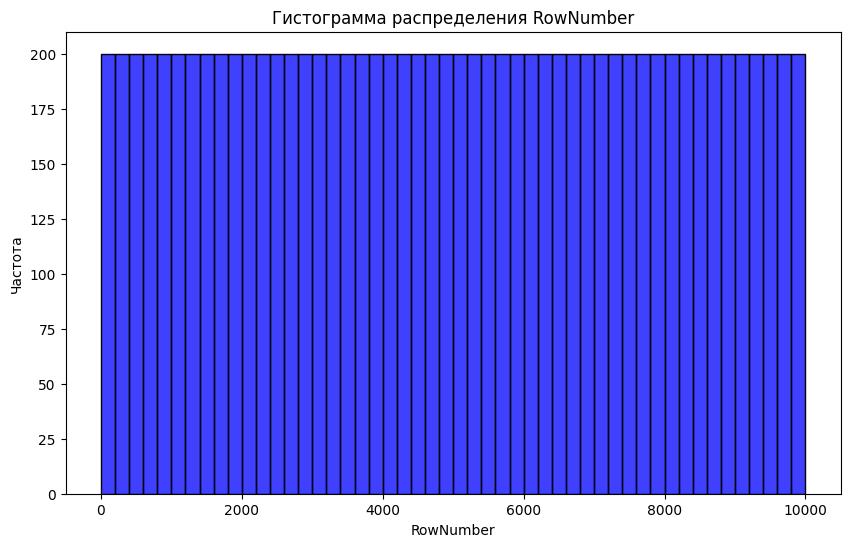

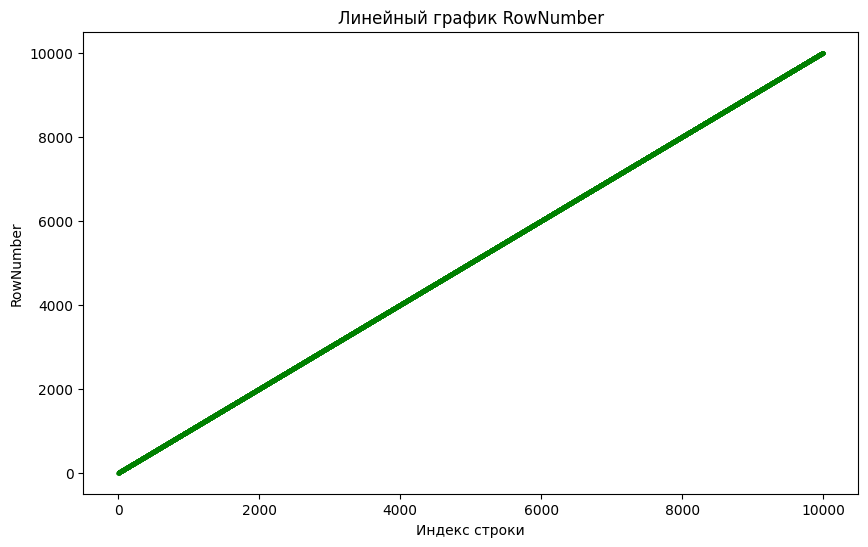

In [18]:

# Построение гистограммы для RowNumber
plt.figure(figsize=(10, 6))
sns.histplot(df['RowNumber'], bins=50, kde=False, color='blue')
plt.title("Гистограмма распределения RowNumber")
plt.xlabel("RowNumber")
plt.ylabel("Частота")
plt.show()

# Построение линейного графика для RowNumber
plt.figure(figsize=(10, 6))
plt.plot(df['RowNumber'], marker='o', linestyle='-', color='green', markersize=2)
plt.title("Линейный график RowNumber")
plt.xlabel("Индекс строки")
plt.ylabel("RowNumber")
plt.show()

In [ ]:
Выводы:<br>
Признак RowNumber является техническим и не несёт смысловой нагрузки для анализа данных. Он просто указывает на порядковый номер строки в таблице.<br>

Все значения уникальны и последовательно увеличиваются от 1 до 10000.<br>

Этот признак можно удалить из данных перед построением моделей, так как он не содержит полезной информации для анализа или прогнозирования.<br>

Описательные статистики для CustomerId:
count    1.000000e+04
mean     1.569094e+07
std      7.193619e+04
min      1.556570e+07
25%      1.562853e+07
50%      1.569074e+07
75%      1.575323e+07
max      1.581569e+07
Name: CustomerId, dtype: float64

Минимальное значение CustomerId: 15565701
Максимальное значение CustomerId: 15815690


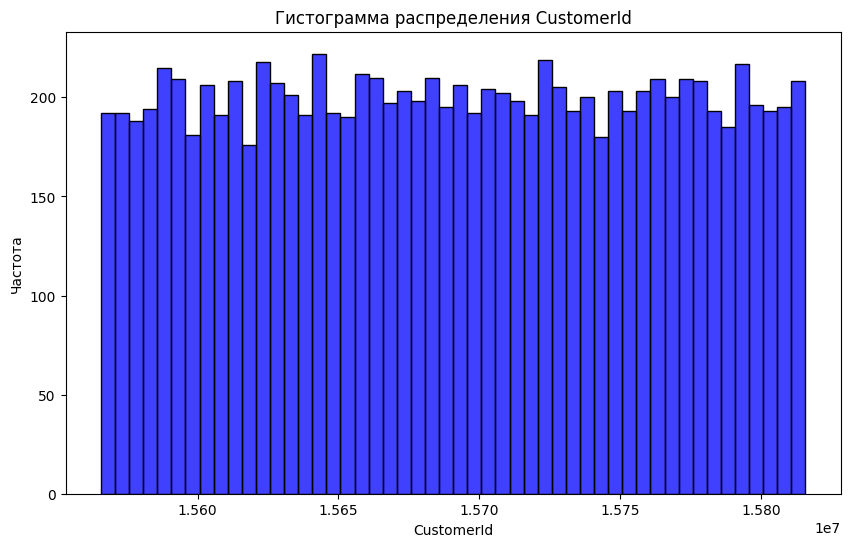

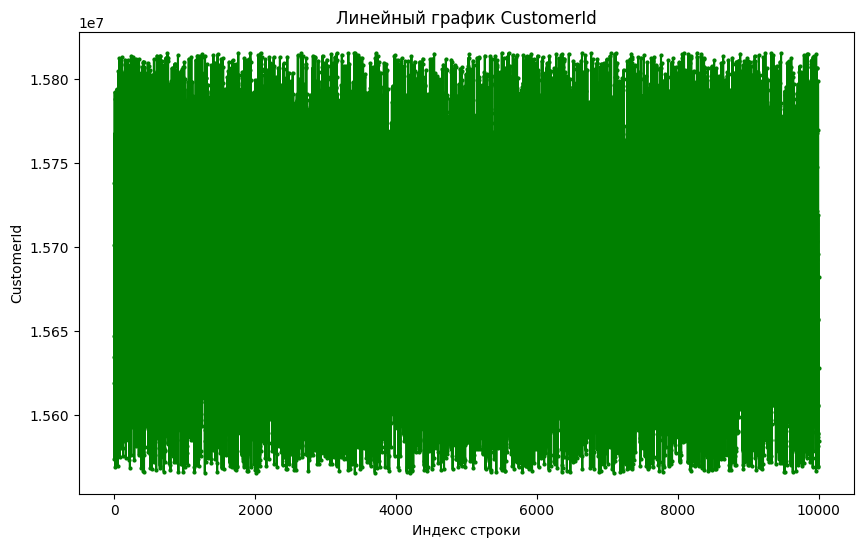

In [21]:

# Изучение признака CustomerId
print("Описательные статистики для CustomerId:")
print(df['CustomerId'].describe())

print("\nМинимальное значение CustomerId:", df['CustomerId'].min())
print("Максимальное значение CustomerId:", df['CustomerId'].max())

# Построение гистограммы для CustomerId
plt.figure(figsize=(10, 6))
sns.histplot(df['CustomerId'], bins=50, kde=False, color='blue')
plt.title("Гистограмма распределения CustomerId")
plt.xlabel("CustomerId")
plt.ylabel("Частота")
plt.show()

# Построение линейного графика для CustomerId
plt.figure(figsize=(10, 6))
plt.plot(df['CustomerId'], marker='o', linestyle='-', color='green', markersize=2)
plt.title("Линейный график CustomerId")
plt.xlabel("Индекс строки")
plt.ylabel("CustomerId")
plt.show()

Выводы:<br>
Признак CustomerId является уникальным идентификатором клиента.<br>
Все значения уникальны и не повторяются.<br>
Этот признак не несёт смысловой нагрузки для анализа данных, так как это просто идентификатор. Его можно удалить перед построением моделей.<br>

Surname

Количество уникальных фамилий: 2932
Наиболее часто встречающаяся фамилия: Smith
Количество её повторений: 32


C:\Users\Admin\AppData\Local\Temp\ipykernel_2988\518274205.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_surnames.index, y=top_surnames.values, palette='viridis')


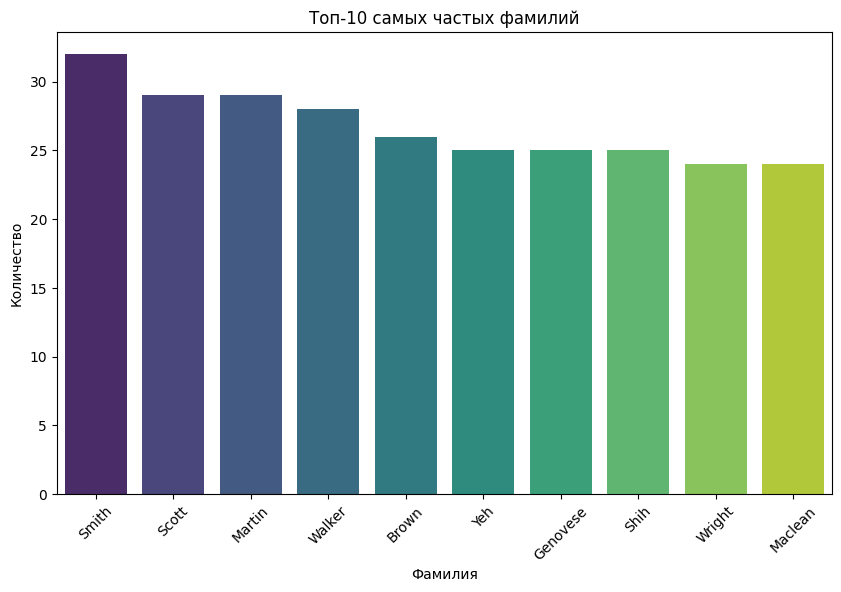

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных из CSV-файла
df = pd.read_csv('Churn_Modelling.csv')

# Изучение признака Surname
print("Количество уникальных фамилий:", df['Surname'].nunique())
print("Наиболее часто встречающаяся фамилия:", df['Surname'].mode()[0])
print("Количество её повторений:", df['Surname'].value_counts().max())

# Топ-10 самых частых фамилий
top_surnames = df['Surname'].value_counts().head(10)

# Построение столбчатой диаграммы для топ-10 фамилий
plt.figure(figsize=(10, 6))
sns.barplot(x=top_surnames.index, y=top_surnames.values, palette='viridis')
plt.title("Топ-10 самых частых фамилий")
plt.xlabel("Фамилия")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.show()

Выводы:
Признак Surname содержит 2932 уникальные фамилии.<br>

Большинство фамилий встречаются редко (только 1-2 раза), но есть несколько фамилий, которые встречаются чаще (например, Smith).<br>

Этот признак может быть полезен для анализа, если фамилии связаны с другими характеристиками клиентов (например, географией или возрастом). Однако в большинстве случаев фамилии не несут полезной информации для моделирования, и их можно удалить. <br>

Exited

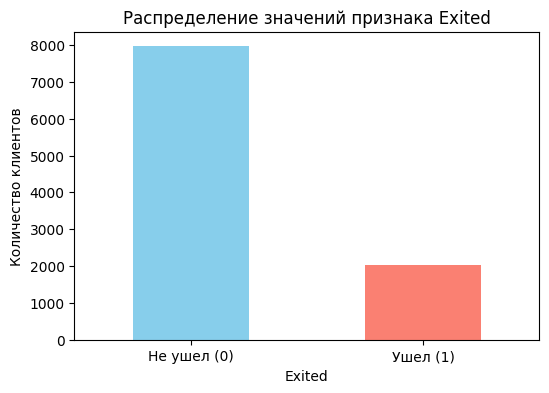

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
data = pd.read_csv('Churn_Modelling.csv')

# Подсчет количества значений в признаке Exited
exited_counts = data['Exited'].value_counts()

# Построение графика
plt.figure(figsize=(6, 4))
exited_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение значений признака Exited')
plt.xlabel('Exited')
plt.ylabel('Количество клиентов')
plt.xticks([0, 1], ['Не ушел (0)', 'Ушел (1)'], rotation=0)
plt.show()

Вывод: значения Exited соответствуют ожидаемым. По данным доля клиентов, покинувших банк - 20%

CreditScore

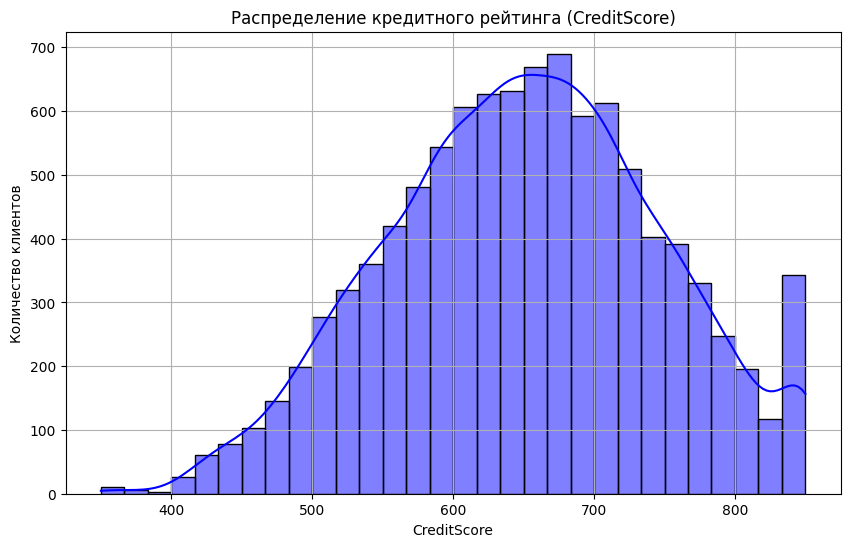

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('Churn_Modelling.csv')

# Построение гистограммы для CreditScore
plt.figure(figsize=(10, 6))
sns.histplot(data['CreditScore'], bins=30, kde=True, color='blue')
plt.title('Распределение кредитного рейтинга (CreditScore)')
plt.xlabel('CreditScore')
plt.ylabel('Количество клиентов')
plt.grid(True)
plt.show()

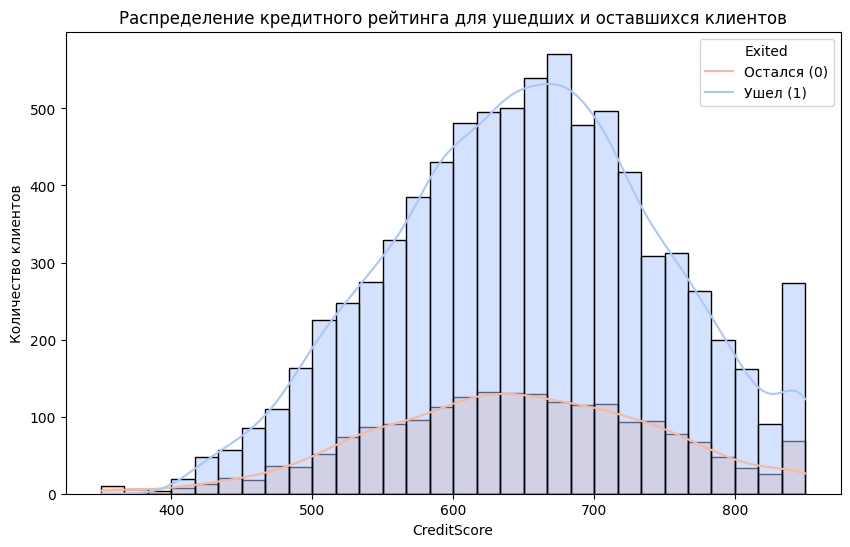

Результат t-теста: t-статистика = 2.7100778888729833, p-значение = 0.006738213892192373
Различия в средних значениях кредитного рейтинга между ушедшими и оставшимися клиентами статистически значимы.


In [28]:

from scipy.stats import ttest_ind


# Визуализация распределения CreditScore для Exited = 0 (остался) и Exited = 1 (ушел)
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='CreditScore', hue='Exited', kde=True, palette='coolwarm', bins=30)
plt.title('Распределение кредитного рейтинга для ушедших и оставшихся клиентов')
plt.xlabel('CreditScore')
plt.ylabel('Количество клиентов')
plt.legend(title='Exited', labels=['Остался (0)', 'Ушел (1)'])
plt.show()

# Статистический тест для проверки значимости различий
# Разделяем данные на две группы: ушедшие (Exited = 1) и оставшиеся (Exited = 0) клиенты
credit_score_exited_0 = data[data['Exited'] == 0]['CreditScore']  # Остались
credit_score_exited_1 = data[data['Exited'] == 1]['CreditScore']  # Ушли

# Проводим t-тест для сравнения средних значений
t_stat, p_value = ttest_ind(credit_score_exited_0, credit_score_exited_1)

print(f"Результат t-теста: t-статистика = {t_stat}, p-значение = {p_value}")

# Интерпретация p-значения
if p_value < 0.05:
    print("Различия в средних значениях кредитного рейтинга между ушедшими и оставшимися клиентами статистически значимы.")
else:
    print("Различия в средних значениях кредитного рейтинга между ушедшими и оставшимися клиентами не являются статистически значимыми.")

Выводы:<br>

Распределение кредитного рейтинга:<br>
График показывает, что кредитный рейтинг клиентов распределен в диапазоне примерно от 400 до 700.<br>
Пик распределения приходится на диапазон 600–700, что указывает на то, что большинство клиентов имеют кредитный рейтинг в этом промежутке.<br>

Типичный кредитный рейтинг:<br>
Большинство клиентов имеют кредитный рейтинг в диапазоне 600–700, что соответствует "удовлетворительному" или "хорошему" уровню кредитоспособности.<br>

Наличие выбросов:<br>
На графике видны клиенты с очень низким кредитным рейтингом (около 400). Это может быть интересно для дальнейшего анализа, так как такие клиенты могут быть более склонны к оттоку или иметь повышенный риск дефолта.<br>

Симметричность распределения:<br>
Распределение выглядит относительно симметричным, с небольшим смещением в сторону более высоких значений кредитного рейтинга. Это указывает на то, что большинство клиентов банка имеют средний или выше среднего уровень кредитоспособности.<br>

Geography 

C:\Users\Admin\AppData\Local\Temp\ipykernel_2988\2122303153.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=geo_counts.index, y=geo_counts.values, palette='viridis')


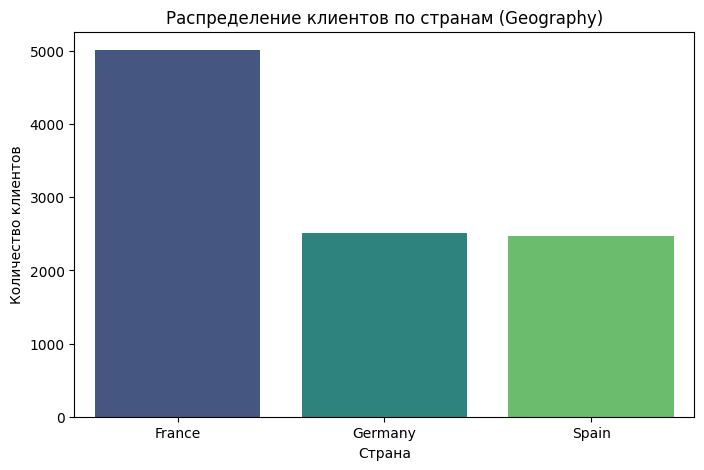

In [29]:

# Подсчет количества клиентов по странам
geo_counts = data['Geography'].value_counts()

# Построение графика
plt.figure(figsize=(8, 5))
sns.barplot(x=geo_counts.index, y=geo_counts.values, palette='viridis')
plt.title('Распределение клиентов по странам (Geography)')
plt.xlabel('Страна')
plt.ylabel('Количество клиентов')
plt.show()

<Figure size 800x500 with 0 Axes>

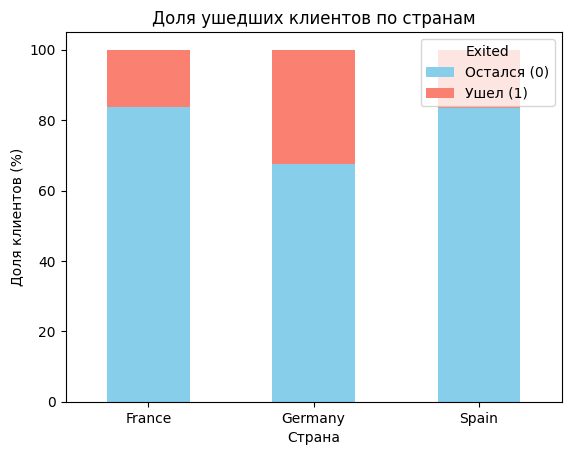

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Загрузка данных
data = pd.read_csv('Churn_Modelling.csv')

# 1. Визуализация: Доля ушедших клиентов по странам
# Группируем данные по странам и считаем долю ушедших клиентов
geo_exited = data.groupby('Geography')['Exited'].value_counts(normalize=True).unstack() * 100

# Построение графика
plt.figure(figsize=(8, 5))
geo_exited.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Доля ушедших клиентов по странам')
plt.xlabel('Страна')
plt.ylabel('Доля клиентов (%)')
plt.legend(title='Exited', labels=['Остался (0)', 'Ушел (1)'])
plt.xticks(rotation=0)
plt.show()



Вывод:<br>

Клиенты из Германии могут быть более склонны к оттоку, чем клиенты из других стран.<br>

Это может быть связано с различными факторами, такими как уровень конкуренции, качество обслуживания или культурные особенности.<br>

Франция является основным рынком для банка, и большинство клиентов сосредоточено именно там.<br>

Германия и Испания представляют меньшую долю клиентской базы.<br>

Gender

C:\Users\Admin\AppData\Local\Temp\ipykernel_2988\1264389162.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')


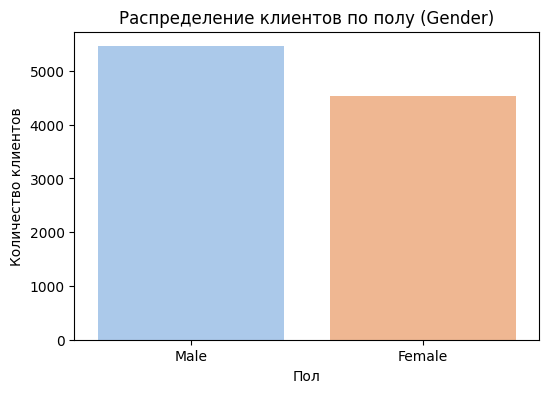

In [33]:

# Подсчет количества клиентов по полу
gender_counts = data['Gender'].value_counts()

# Построение графика
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')
plt.title('Распределение клиентов по полу (Gender)')
plt.xlabel('Пол')
plt.ylabel('Количество клиентов')
plt.show()

<Figure size 600x400 with 0 Axes>

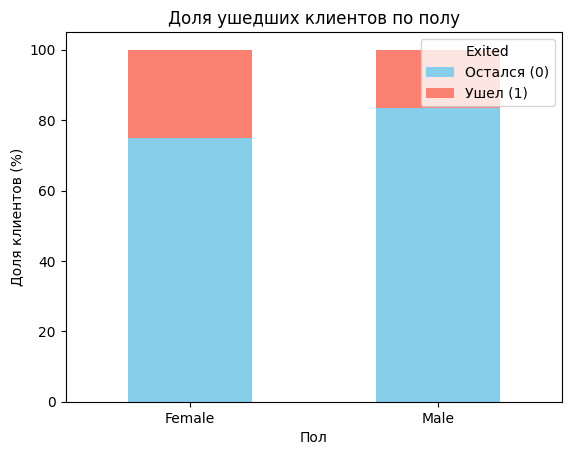

In [35]:


# 1. Визуализация: Доля ушедших клиентов по полу
# Группируем данные по полу и считаем долю ушедших клиентов
gender_exited = data.groupby('Gender')['Exited'].value_counts(normalize=True).unstack() * 100

# Построение графика
plt.figure(figsize=(6, 4))
gender_exited.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Доля ушедших клиентов по полу')
plt.xlabel('Пол')
plt.ylabel('Доля клиентов (%)')
plt.legend(title='Exited', labels=['Остался (0)', 'Ушел (1)'])
plt.xticks(rotation=0)
plt.show()



Вывод:<br>

пол может влиять на решение покинуть банк

Age

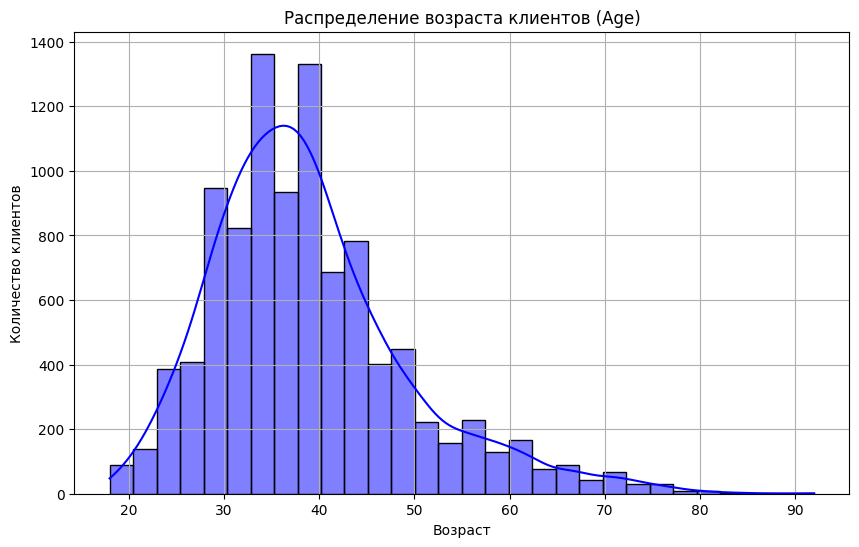

In [37]:


# Построение гистограммы для Age
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=30, kde=True, color='blue')
plt.title('Распределение возраста клиентов (Age)')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.grid(True)
plt.show()

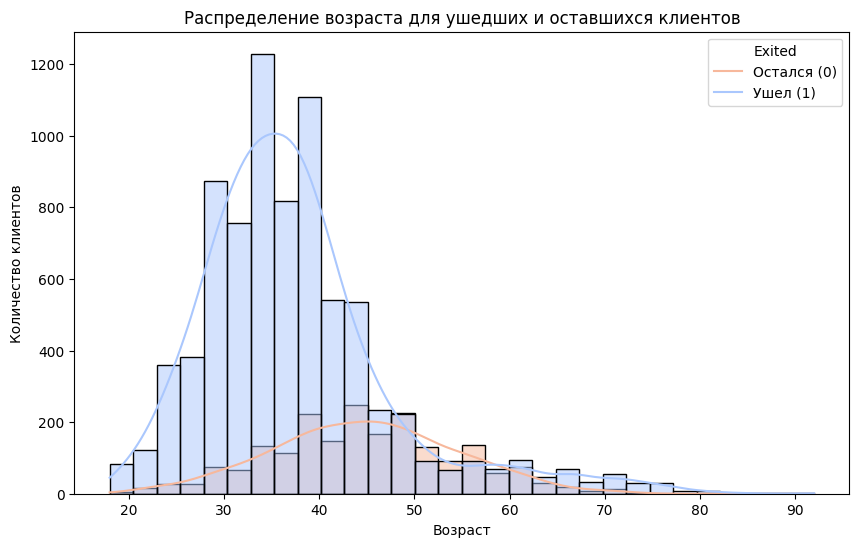

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Загрузка данных
data = pd.read_csv('Churn_Modelling.csv')

# 1. Визуализация: Распределение возраста для ушедших и оставшихся клиентов
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Age', hue='Exited', kde=True, palette='coolwarm', bins=30)
plt.title('Распределение возраста для ушедших и оставшихся клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.legend(title='Exited', labels=['Остался (0)', 'Ушел (1)'])
plt.show()


Вывод:<br>

Распредление отличается от нормального и для возраста это нормально<br>
Возможно, старшее поколение чаще отказывается от услуг банка

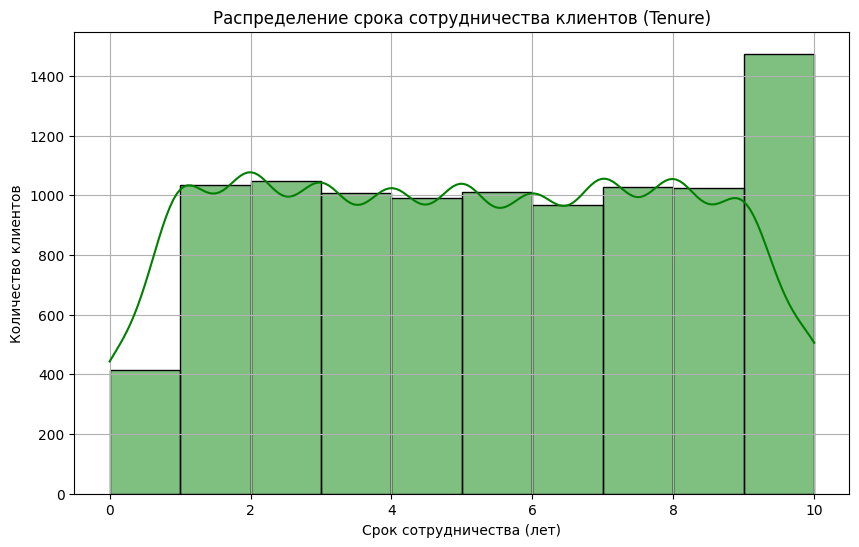

In [41]:


# Построение гистограммы для Tenure
plt.figure(figsize=(10, 6))
sns.histplot(data['Tenure'], bins=10, kde=True, color='green')
plt.title('Распределение клиентов по сроку пребывания в разрезе статуса отписки')
plt.xlabel('Срок сотрудничества (лет)')
plt.ylabel('Количество клиентов')
plt.grid(True)
plt.show()

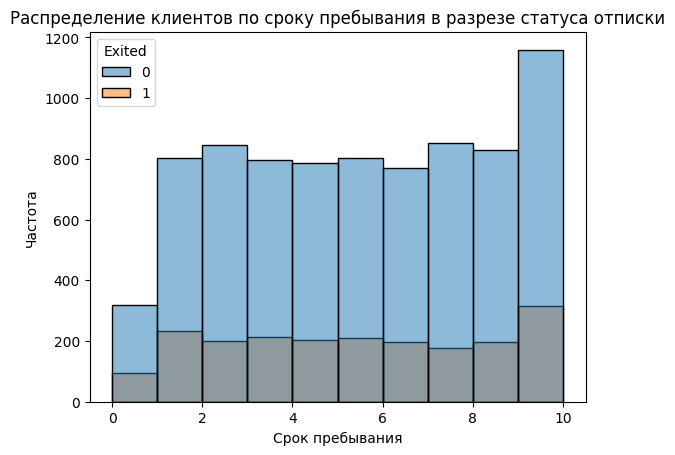

In [43]:
ax = sns.histplot(df, x='Tenure', bins=10, hue='Exited')
ax.set_xlabel('Срок пребывания')
ax.set_ylabel('Частота')
ax.set_title('Распределение клиентов по сроку пребывания в разрезе статуса отписки')

plt.show()

Вывод:
распредление близко к равномерному


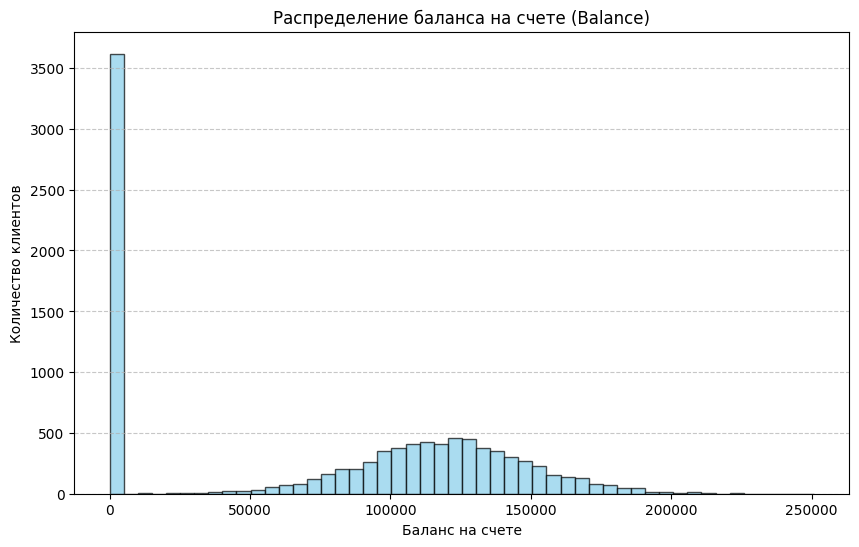

In [50]:


# Построение гистограммы для Balance
plt.figure(figsize=(10, 6))
plt.hist(data['Balance'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение баланса на счете (Balance)')
plt.xlabel('Баланс на счете')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

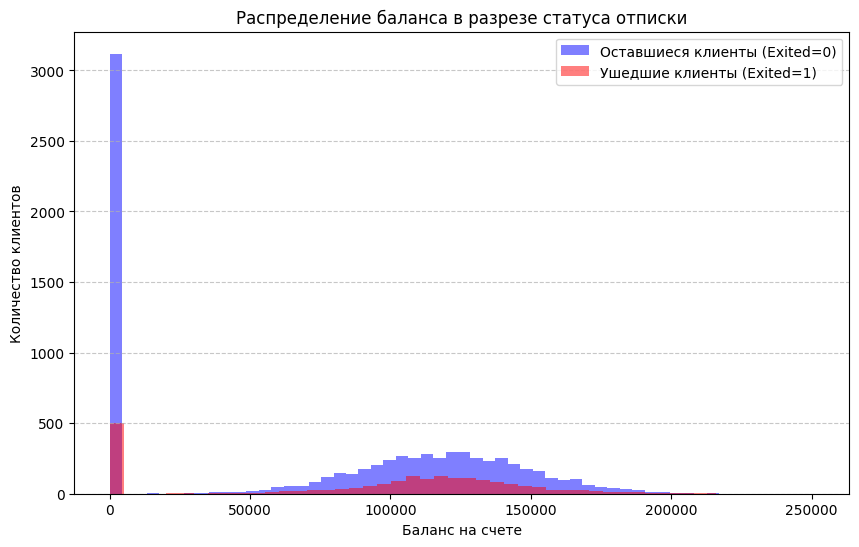

In [49]:

# Построение гистограммы с разделением по Exited
plt.figure(figsize=(10, 6))
plt.hist(data[data['Exited'] == 0]['Balance'], bins=50, alpha=0.5, label='Оставшиеся клиенты (Exited=0)', color='blue')
plt.hist(data[data['Exited'] == 1]['Balance'], bins=50, alpha=0.5, label='Ушедшие клиенты (Exited=1)', color='red')
plt.title('Распределение баланса в разрезе статуса отписки')
plt.xlabel('Баланс на счете')
plt.ylabel('Количество клиентов')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Вывод:<br>

Много клиентов с нулевым балансом<br>
Среди клиентов с нулевым балансом доля отказов выше, чем среди клиентов с ненулевым балансом

NumOfProducts 

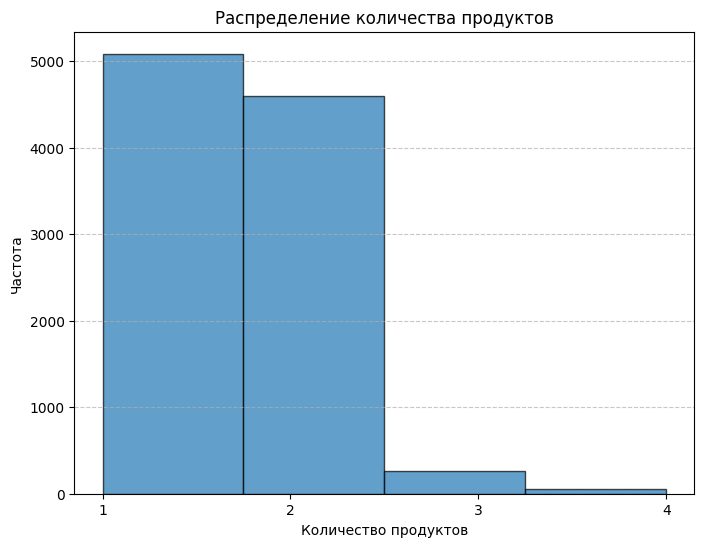

In [5]:

# Построение графика распределения значений NumOfProducts
plt.figure(figsize=(8, 6))
plt.hist(data['NumOfProducts'], bins=4, edgecolor='black', alpha=0.7)
plt.title('Распределение количества продуктов')
plt.xlabel('Количество продуктов')
plt.ylabel('Частота')
plt.xticks(range(1, 5))  # Устанавливаем метки на оси X от 1 до 4
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

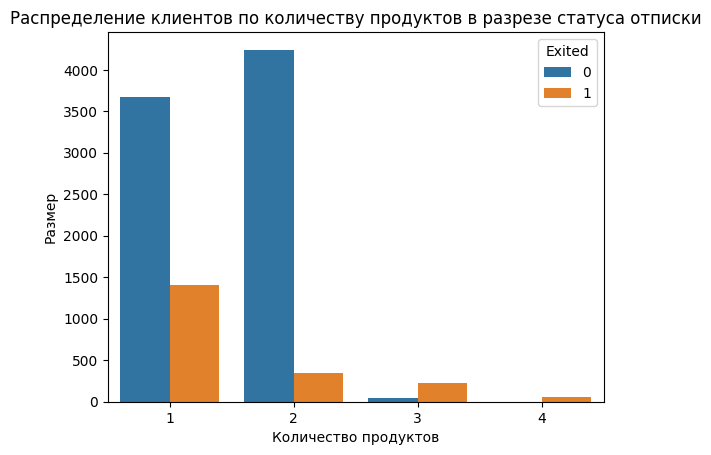

In [4]:
ax = sns.barplot(df.groupby(['NumOfProducts', 'Exited'], as_index=False).size(), x='NumOfProducts', y='size', hue='Exited')
ax.set_xlabel('Количество продуктов')
ax.set_ylabel('Размер')
ax.set_title('Распределение клиентов по количеству продуктов в разрезе статуса отписки')

plt.show()

Вывод:<br>
больше всего клиентов у кого 1 продукт <br>
клиентов у кого 3 и 4 продукта очень мало, поэтому можно их обхединить в 1 группу

HasCrCard 

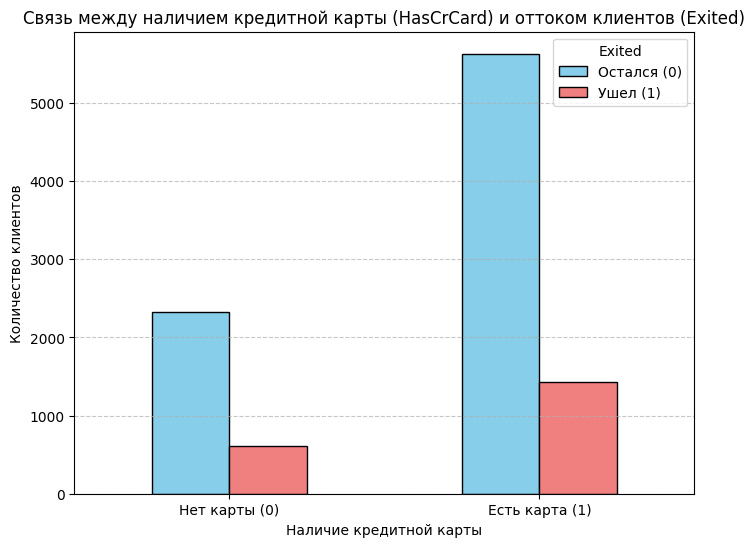

In [10]:

# Создание таблицы сопряженности
cross_tab = pd.crosstab(data['HasCrCard'], data['Exited'])

# Переименуем столбцы для лучшей читаемости
cross_tab.columns = ['Остался (0)', 'Ушел (1)']

# Построение группированной столбчатой диаграммы
cross_tab.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'lightcoral'], edgecolor='black')
plt.title('Связь между наличием кредитной карты (HasCrCard) и оттоком клиентов (Exited)')
plt.xlabel('Наличие кредитной карты')
plt.ylabel('Количество клиентов')
plt.xticks([0, 1], ['Нет карты (0)', 'Есть карта (1)'], rotation=0)
plt.legend(title='Exited')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 Вывод: у большей части клиентов имеется кредитная карта, однако ее наличие не влияет на решение о том, чтобы покинуть банк

IsActiveMember 

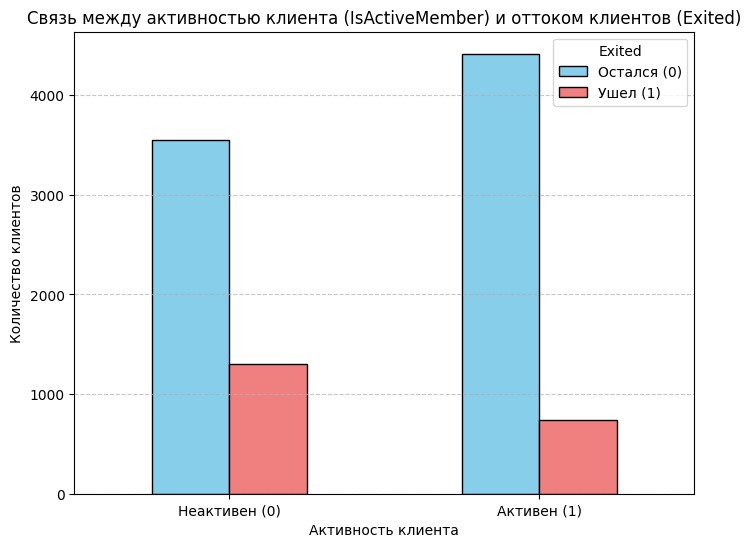

In [11]:

# Создание таблицы сопряженности
cross_tab = pd.crosstab(data['IsActiveMember'], data['Exited'])

# Переименуем столбцы для лучшей читаемости
cross_tab.columns = ['Остался (0)', 'Ушел (1)']

# Построение группированной столбчатой диаграммы
cross_tab.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'lightcoral'], edgecolor='black')
plt.title('Связь между активностью клиента (IsActiveMember) и оттоком клиентов (Exited)')
plt.xlabel('Активность клиента')
plt.ylabel('Количество клиентов')
plt.xticks([0, 1], ['Неактивен (0)', 'Активен (1)'], rotation=0)
plt.legend(title='Exited')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Вывод: неактивные клиенты отказываются от услугбанка почти в 2 раза чаще

EstimatedSalary 

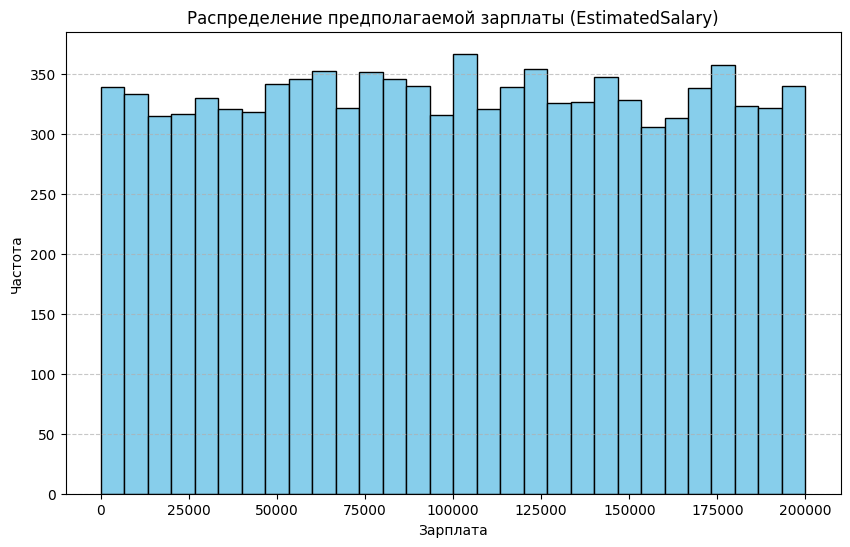

In [12]:

# Построение гистограммы распределения EstimatedSalary
plt.figure(figsize=(10, 6))
plt.hist(data['EstimatedSalary'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение предполагаемой зарплаты (EstimatedSalary)')
plt.xlabel('Зарплата')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

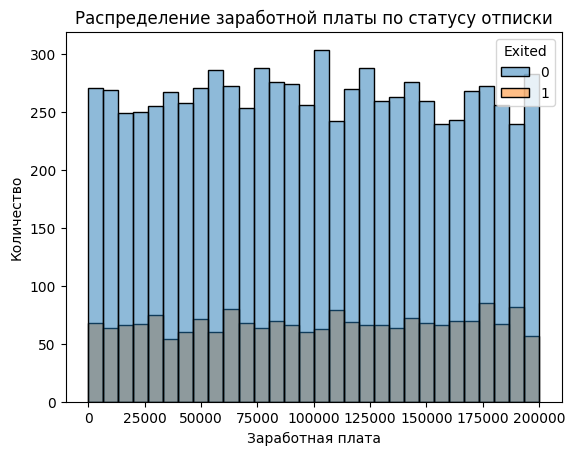

In [14]:
ax = sns.histplot(df, x='EstimatedSalary', bins=30, hue='Exited')
ax.set_xlabel('Заработная плата')
ax.set_ylabel('Количество')
ax.set_title('Распределение заработной платы по статусу отписки')

plt.show()

Выод: Распределения похожи, вероятно, нет влияения на целевую переменную

Корреляции и зависимость между переменными

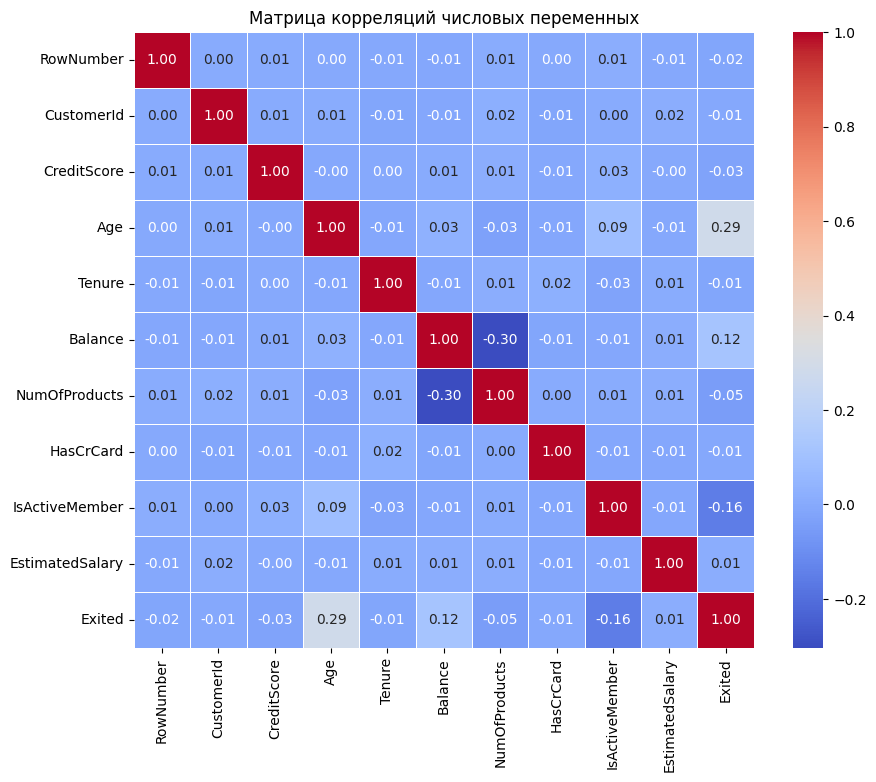

In [15]:

# Выбор только числовых переменных
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Построение матрицы корреляций
correlation_matrix = df[numeric_columns].corr()

# Визуализация матрицы корреляций с помощью тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Матрица корреляций числовых переменных")
plt.show()

Рассмотрим зависимости между нецелевыми переменными

Geography и Balance

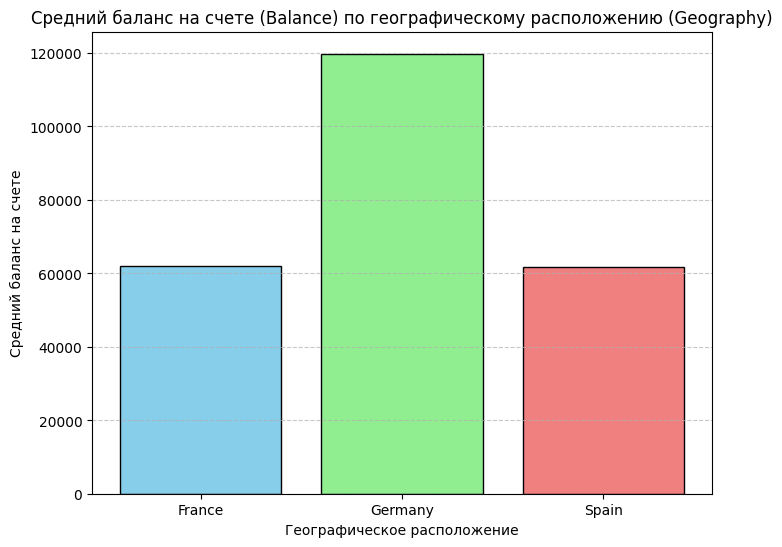

In [16]:

# Группировка данных по Geography и вычисление среднего Balance
grouped_data = data.groupby('Geography')['Balance'].mean().reset_index()

# Построение столбчатой диаграммы
plt.figure(figsize=(8, 6))
plt.bar(grouped_data['Geography'], grouped_data['Balance'], color=['skyblue', 'lightgreen', 'lightcoral'], edgecolor='black')
plt.title('Средний баланс на счете (Balance) по географическому расположению (Geography)')
plt.xlabel('Географическое расположение')
plt.ylabel('Средний баланс на счете')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Вывод: больший баланс у клиентов из Германии

Age и NumOfProducts

C:\Users\Admin\AppData\Local\Temp\ipykernel_1224\4044959401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age', y='NumOfProducts', data=age_product, palette='viridis')


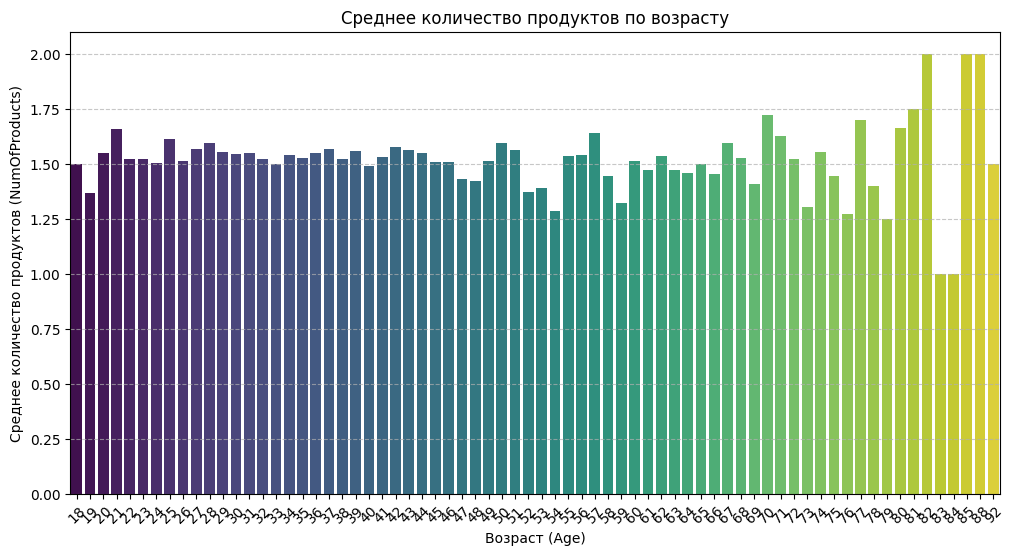

In [6]:


# Группировка данных по возрасту и вычисление среднего количества продуктов
age_product = df.groupby('Age')['NumOfProducts'].mean().reset_index()

# Создание столбчатой диаграммы
plt.figure(figsize=(12, 6))
sns.barplot(x='Age', y='NumOfProducts', data=age_product, palette='viridis')
plt.title('Среднее количество продуктов по возрасту')
plt.xlabel('Возраст (Age)')
plt.ylabel('Среднее количество продуктов (NumOfProducts)')
plt.xticks(rotation=45)  # Поворот меток оси X для лучшей читаемости
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Вывод: в среднем у клиентов 1,5 продуктам, распредление нормальное

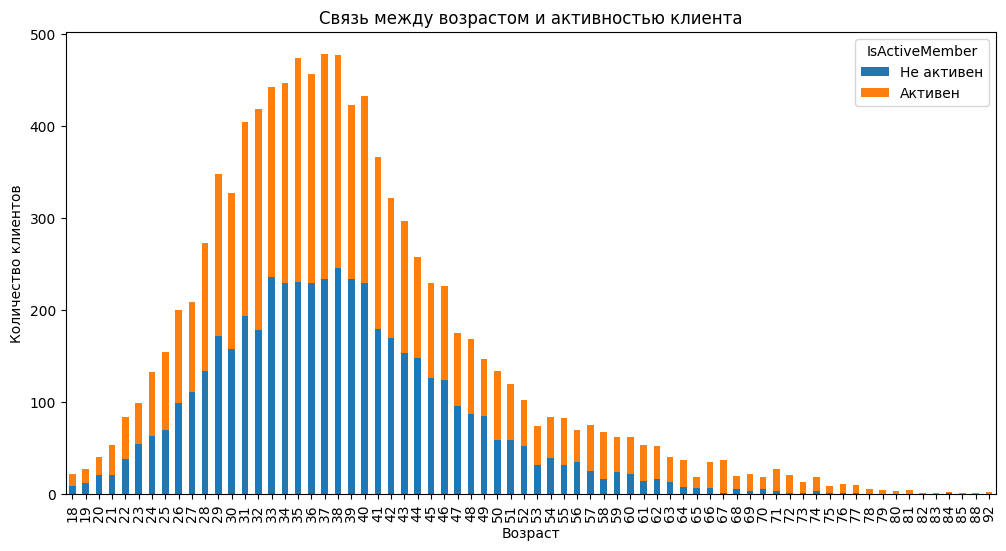

In [8]:


# Группировка данных по возрасту и активности
age_active = df.groupby(['Age', 'IsActiveMember']).size().unstack()

# Построение столбчатой диаграммы
age_active.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Связь между возрастом и активностью клиента')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.legend(title='IsActiveMember', labels=['Не активен', 'Активен'])
plt.show()

Выводы: клиенты молодого и среднего возраста больше актвиных , что достаточно ожидаемо

ИТОГОВЫЕ ВЫВОДЫ:

1) Датасет не содержит дублей и пропущенных значений.<br>
2) RowNumber, CustomerID, Surname  не несут смысла.<br>
Переменные с дисбалансом в классах / смещенным распределением<br>
Exited (целевая): соотношение классов 20 / 80<br>
Geography: соотношение классов примерно 50 / 25 / 25<br>
Age: распределение смещено влево, нужно преобразование<br>
Balance: около трети клиентов имеют нулевой баланс, распределение клиентов с ненулым балансов близко к нормальному<br>
NumOfProducts: мало клиентов, имещих 3 или 4 прдукта, можно их объединить в один класс<br>
HasCrCard: соотношение классов 30 / 70<br>
Целевая переменная Exited больше всего зависит от:<br>
NumOfProducts, Age - но есть вероятность, что это совпадение<br>

Зависимости между нецелевыми переменными:<br>
Geography и Balance - вызвано тем, что в Германии нет клиентов с нулевым балансом<br>
Age и NumOfProducts - кажется, что у клиентов старшего возраста больше продуктов, но, возможно, это искажение из-за того, что молодых клиентов больше<br>
Age и IsActiveMember - аналогично<br>
Balance и NumOfProducts - в целом форма распределения похожа, но надо быть осторожнее, тк классы NumOfProducts не сбаланисрованы
